In [12]:
import functools
import matplotlib.pyplot as plt
import numpy as np
import torch
import seaborn as sns

sns.set_theme()
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device('cpu')

if torch.cuda.is_available():
    torch.empty(1).to(DEVICE)

print(f"PyTorch will use: {DEVICE}")

PyTorch will use: cuda


In [13]:
def grad(outputs, inputs):
    return torch.autograd.grad(
        outputs, inputs, grad_outputs=torch.ones_like(outputs), create_graph=True
    )


def cooling_law(time, Tenv, T0, R):
    T = Tenv + (T0 - Tenv) * np.exp(-R * time)
    return T


In [14]:
import torch
import torch.nn as nn
import torch.optim as optim

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def np_to_th(x):
    n_samples = len(x)
    return torch.from_numpy(x).to(torch.float).to(DEVICE).reshape(n_samples, -1)

class Net(nn.Module):
    def __init__(
        self,
        input_dim,
        output_dim,
        n_units=100,
        epochs=1000,
        loss=nn.MSELoss(),
        lr=1e-3,
        loss2=None,
        loss2_weight=0.1,
    ) -> None:
        super().__init__()

        self.epochs = epochs
        self.loss = loss
        self.loss2 = loss2
        self.loss2_weight = loss2_weight
        self.lr = lr
        self.n_units = n_units

        self.layers = nn.Sequential(
            nn.Linear(input_dim, self.n_units),
            nn.SiLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.SiLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.SiLU(),
            nn.Linear(self.n_units, self.n_units),
            nn.SiLU(),
        )
        self.out = nn.Linear(self.n_units, output_dim)

    def forward(self, x):
        h = self.layers(x)
        out = self.out(h)
        return out

    def fit(self, X, y):
        Xt = np_to_th(X)
        yt = np_to_th(y)

        optimiser = optim.Adam(self.parameters(), lr=self.lr)
        self.train()
        losses = []
        for ep in range(self.epochs):
            optimiser.zero_grad()
            outputs = self.forward(Xt)
            loss = self.loss(yt, outputs)
            if self.loss2:
                loss += self.loss2_weight * self.loss2(self)
            loss.backward()
            optimiser.step()
            losses.append(loss.item())

            # Custom callback for discovery
            if hasattr(self, 'r_history'):
                self.r_history.append(self.r.item())

            if ep % int(self.epochs / 10) == 0:
                print(f"Epoch {ep}/{self.epochs}, loss: {losses[-1]:.4f}")
        return losses

    def predict(self, X):
        self.eval()
        out = self.forward(np_to_th(X))
        return out.detach().cpu().numpy()

class NetDiscovery(Net):
    def __init__(
        self,
        input_dim,
        output_dim,
        n_units=100,
        epochs=1000,
        loss=nn.MSELoss(),
        lr=0.001,
        loss2=None,
        loss2_weight=0.1,
    ) -> None:
        super().__init__(
            input_dim, output_dim, n_units, epochs, loss, lr, loss2, loss2_weight
        )
        self.r = nn.Parameter(data=torch.tensor([0.001]))
        self.r_history = []

Text(0.5, 0, 'Time (s)')

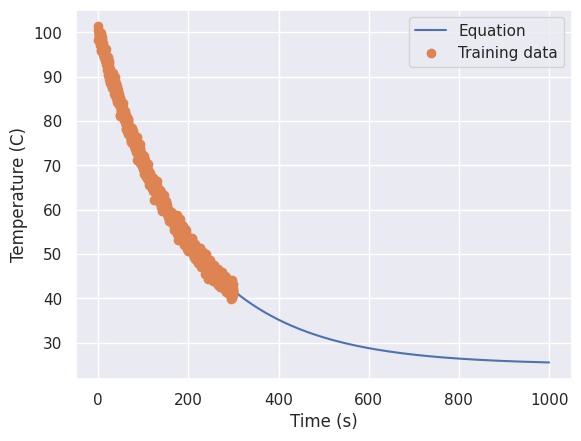

In [15]:
np.random.seed(10)

Tenv = 25
T0 = 100
R = 0.005
number_of_points = 1000
noise_coeff = 1

times = np.linspace(0, 1000, number_of_points)
eq = functools.partial(cooling_law, Tenv=Tenv, T0=T0, R=R)
temps = eq(times)

# Make training data
t = np.linspace(0, 300, number_of_points)
T = eq(t) + noise_coeff * np.random.randn(number_of_points)

plt.plot(times, temps)
plt.plot(t, T, 'o')
plt.legend(['Equation', 'Training data'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')

# PINN

In [16]:
def physics_loss(model: torch.nn.Module, n_points=5000):
    ts = torch.linspace(0, 1000, steps=n_points,).view(-1,1).requires_grad_(True).to(DEVICE)
    temps = model(ts)
    dT = grad(temps, ts)[0]
    pde = R*(Tenv - temps) - dT

    return torch.mean(pde**2)

Epoch 0/30000, loss: 4519.7183
Epoch 3000/30000, loss: 2048.4602
Epoch 6000/30000, loss: 1621.6658
Epoch 9000/30000, loss: 82.2116
Epoch 12000/30000, loss: 34.0189
Epoch 15000/30000, loss: 18.0514
Epoch 18000/30000, loss: 3.9487
Epoch 21000/30000, loss: 1.0123
Epoch 24000/30000, loss: 0.9076
Epoch 27000/30000, loss: 0.8812


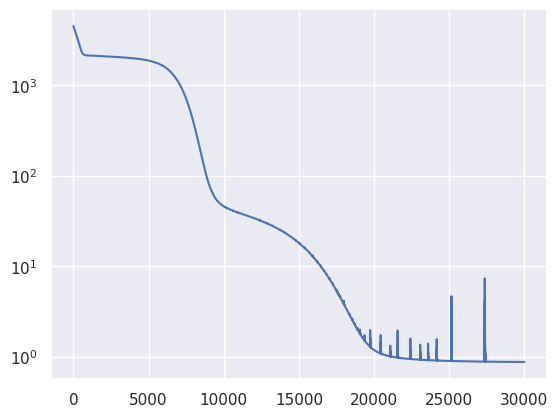

In [17]:
net = Net(1,1, loss2=physics_loss, epochs=30000, loss2_weight=50, lr=1e-5).to(DEVICE)

losses = net.fit(t, T)
plt.plot(losses)
plt.yscale('log')

Text(0.5, 0, 'Time (s)')

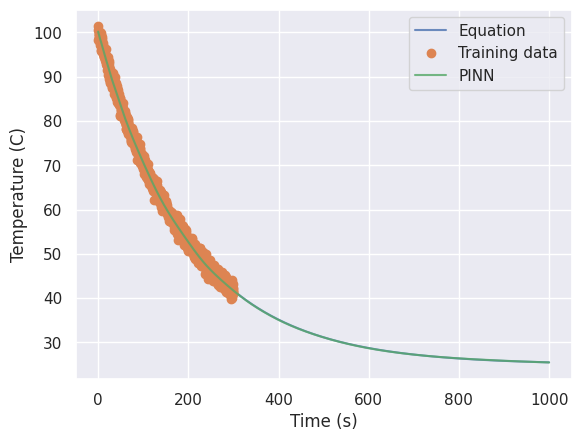

In [22]:
preds = net.predict(times)

plt.plot(times, temps, alpha=0.8)
plt.plot(t, T, 'o')
plt.plot(times, preds, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'PINN'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')

# Parameter discovery

In [ ]:
def physics_loss_discovery(model: torch.nn.Module, n_points=10000):
    # ts = torch.linspace(0, 1000, steps=n_points,).view(-1,1).requires_grad_(True).to(DEVICE)
    ts = (torch.rand(n_points, 1, device=DEVICE) * 1000).requires_grad_(True) # random points

    temps = model(ts)
    dT = grad(temps, ts)[0]
    pde = torch.abs(model.r) * (Tenv - temps) - dT

    return torch.mean(pde**2)

Epoch 0/100000, loss: 4569.2476
Epoch 10000/100000, loss: 1767.8882
Epoch 20000/100000, loss: 55.2301
Epoch 30000/100000, loss: 5.3348
Epoch 40000/100000, loss: 0.8928
Epoch 50000/100000, loss: 0.8716
Epoch 60000/100000, loss: 0.8914
Epoch 70000/100000, loss: 0.8700
Epoch 80000/100000, loss: 0.8732
Epoch 90000/100000, loss: 0.8707


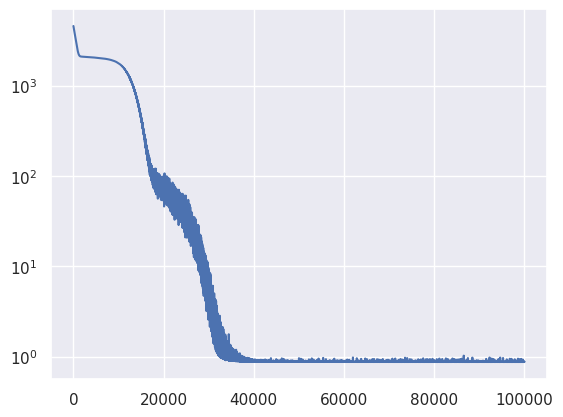

In [24]:
netdisc = NetDiscovery(1, 1, loss2=physics_loss_discovery, loss2_weight=100, epochs=100000, lr=5e-6).to(DEVICE)

losses = netdisc.fit(t, T)

plt.plot(losses)
plt.yscale('log')

Parameter containing:
tensor([0.0050], device='cuda:0', requires_grad=True)


Text(0.5, 0, 'Time (s)')

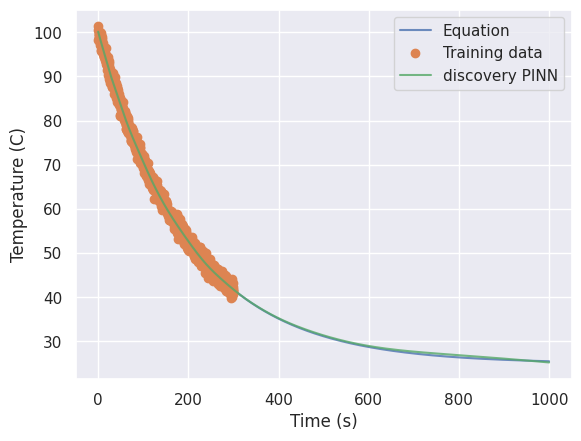

In [25]:
preds = netdisc.predict(times)
print(netdisc.r)

plt.plot(times, temps, alpha=0.8)
plt.plot(t, T, 'o')
plt.plot(times, preds, alpha=0.8)
plt.legend(labels=['Equation','Training data', 'discovery PINN'])
plt.ylabel('Temperature (C)')
plt.xlabel('Time (s)')